# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [2]:

# Load the dataset
df = pd.read_csv('colorectal_cancer_prediction.csv')

# Display basic information about the dataset

df.head()

,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [9]:

# Check for missing values
import pandas as pd

# Load dataset
df = pd.read_csv('colorectal_cancer_prediction.csv')

# Display first rows
print(df.head())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal missing values in dataset:", df.isnull().sum().sum())









   Patient_ID  Age  Gender   Race         Region Urban_or_Rural  \
0           1   71    Male  Other         Europe          Urban   
1           2   34  Female  Black  North America          Urban   
2           3   80  Female  White  North America          Urban   
3           4   40    Male  Black  North America          Rural   
4           5   43  Female  White         Europe          Urban   

  Socioeconomic_Status Family_History Previous_Cancer_History  \
0               Middle            Yes                      No   
1               Middle             No                      No   
2               Middle             No                      No   
3                  Low             No                      No   
4                 High            Yes                      No   

  Stage_at_Diagnosis  ... Insurance_Coverage Time_to_Diagnosis  \
0                III  ...                Yes           Delayed   
1                  I  ...                 No            Timely   
2       

Index(['Patient_ID', 'Age', 'Gender', 'Race', 'Region', 'Urban_or_Rural',
       'Socioeconomic_Status', 'Family_History', 'Previous_Cancer_History',
       'Stage_at_Diagnosis', 'Tumor_Aggressiveness', 'Colonoscopy_Access',
       'Screening_Regularity', 'Diet_Type', 'BMI', 'Physical_Activity_Level',
       'Smoking_Status', 'Alcohol_Consumption', 'Red_Meat_Consumption',
       'Fiber_Consumption', 'Insurance_Coverage', 'Time_to_Diagnosis',
       'Treatment_Access', 'Chemotherapy_Received', 'Radiotherapy_Received',
       'Surgery_Received', 'Follow_Up_Adherence', 'Survival_Status',
       'Recurrence', 'Time_to_Recurrence'],
      dtype='object')


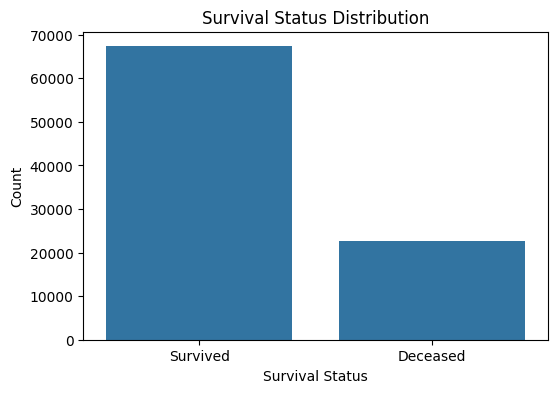

In [8]:

print(df.columns)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=df['Survival_Status'])
plt.title("Survival Status Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Count")
plt.show()



Numerical Columns:
Index(['Patient_ID', 'Age', 'BMI', 'Time_to_Recurrence'], dtype='object')


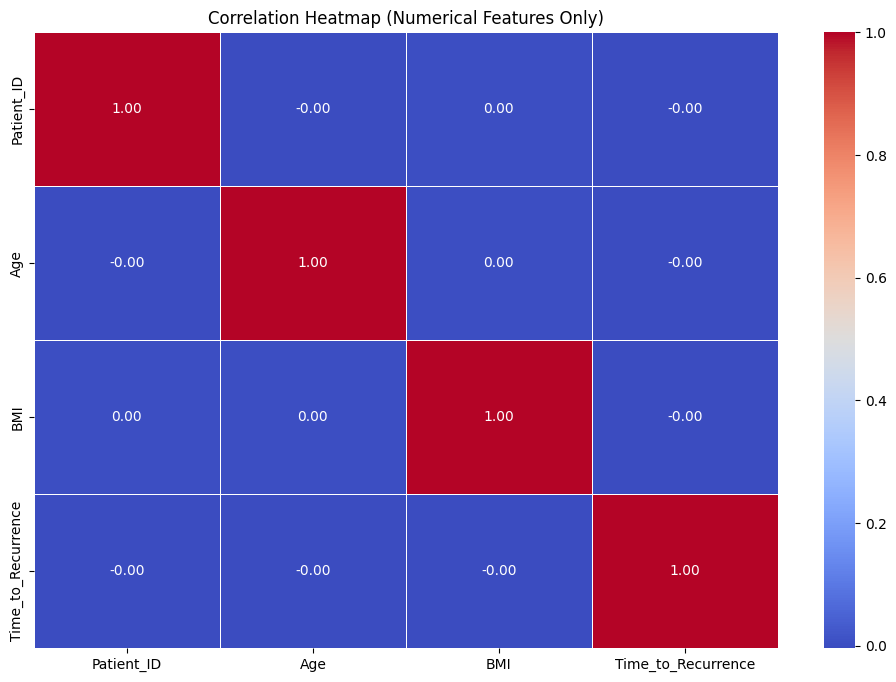

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical features
numerical_df = df.select_dtypes(include=['int64', 'float64'])

print("Numerical Columns:")
print(numerical_df.columns)

# Compute correlation matrix
corr = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()


## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Reload the dataset to ensure a clean state for preprocessing
df = pd.read_csv('colorectal_cancer_prediction.csv')

# ------------------------------------
# 1. HANDLE MISSING VALUES
# ------------------------------------
# Fill missing numerical with mean, categorical with mode
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].mean()) # Avoid inplace=True for FutureWarning
    else:
        df[col] = df[col].fillna(df[col].mode()[0]) # Avoid inplace=True for FutureWarning

# ------------------------------------
# 2. DROP UNNECESSARY COLUMNS
# ------------------------------------
if 'Patient_ID' in df.columns:
    df.drop(columns=['Patient_ID'], inplace=True)

# ------------------------------------
# 3. DEFINE FEATURES AND TARGET FIRST
# ------------------------------------
target_column = "Survival_Status"

# Separate target variable from features
X = df.drop(columns=[target_column])
y = df[target_column]

# ------------------------------------
# 4. ENCODE CATEGORICAL VARIABLES FOR FEATURES (X)
# ------------------------------------
cat_cols_X = X.select_dtypes(include=['object']).columns
label_encoders = {}

if not cat_cols_X.empty:
    for col in cat_cols_X:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le
    print("Encoded Categorical Features (X):")
    print(cat_cols_X)
else:
    print("No categorical features (X) to encode.")

# ------------------------------------
# 5. ENCODE THE TARGET VARIABLE (y)
# ------------------------------------
if y.dtype == 'object': # Only encode if it's still an object (e.g., 'Survived', 'Deceased')
    le_y = LabelEncoder()
    y = le_y.fit_transform(y)
    print(f"Target variable '{target_column}' label-encoded.")
else:
    print(f"Target variable '{target_column}' is already numerical (dtype: {y.dtype}).")


# ------------------------------------
# 6. NORMALIZE NUMERICAL FEATURES (X)
# ------------------------------------
num_cols_X = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[num_cols_X] = scaler.fit_transform(X[num_cols_X])
print("Numerical Features (X) scaled.")


# ------------------------------------
# 7. TRAIN-TEST SPLIT
# ------------------------------------
# y is already a numpy array at this point, so no need for .values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Encoded Categorical Features (X):
Index(['Gender', 'Race', 'Region', 'Urban_or_Rural', 'Socioeconomic_Status',
       'Family_History', 'Previous_Cancer_History', 'Stage_at_Diagnosis',
       'Tumor_Aggressiveness', 'Colonoscopy_Access', 'Screening_Regularity',
       'Diet_Type', 'Physical_Activity_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Red_Meat_Consumption', 'Fiber_Consumption',
       'Insurance_Coverage', 'Time_to_Diagnosis', 'Treatment_Access',
       'Chemotherapy_Received', 'Radiotherapy_Received', 'Surgery_Received',
       'Follow_Up_Adherence', 'Recurrence'],
      dtype='object')
Target variable 'Survival_Status' label-encoded.
Numerical Features (X) scaled.
Train shape: (71956, 28)
Test shape: (17989, 28)


## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [22]:
# REMOVE target from scaling safely
if 'Survival_Status' in num_cols:
    num_cols = num_cols.drop('Survival_Status')
# SAFE DROP
num_cols = num_cols.drop(['Survival_Status'], errors='ignore')

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7486797487353383

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      4521
           1       0.75      1.00      0.86     13468

    accuracy                           0.75     17989
   macro avg       0.37      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
